<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week-1 Assignment

# Titanic: Survival Analysis

**Welcome to your first bonus assignment! The dataset you'll be working with is the legendary Titanic passenger dataset - one of the most famous datasets in data science.**

**The Titanic sank on April 15, 1912 after colliding with an iceberg. Of 2,224 passengers and crew aboard, only 710 survived. This dataset captures information about 891 of those passengers and your job is to explore it using Pandas and data visualization.**

**We have a set of questions for you that will build your understanding of data manipulation and visualization. GOOD LUCK!**

---

**Dataset columns:**
| Column | Description |
|--------|-------------|
| PassengerId | Unique ID for each passenger |
| Survived | 0 = Did not survive, 1 = Survived |
| Pclass | Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd) |
| Name | Passenger name |
| Sex | Gender |
| Age | Age in years |
| SibSp | # of siblings/spouses aboard |
| Parch | # of parents/children aboard |
| Ticket | Ticket number |
| Fare | Passenger fare |
| Cabin | Cabin number |
| Embarked | Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) |

---

*Let's get started with importing numpy, pandas, seaborn and matplotlib!*

**Note** - matplotlib should be imported with the command:

`import matplotlib.pyplot as plt`

## Warm-Up Questions

These questions are **ungraded** and help you get comfortable with the dataset.

### 1) Import all important libraries
Import `numpy`, `pandas`, `seaborn`, and `matplotlib.pyplot`.

In [277]:
# your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2) Read the CSV file and assign it to a variable
Load `W1_Titanic.csv` into a DataFrame.

In [278]:
# your code here
df = pd.read_csv("W1_Titanic.csv")

### 3) Display the shape of the DataFrame
Expected Output: `(891, 12)`

In [279]:
# your code here
df.shape

(891, 12)

### 4) Print all column names of the DataFrame
Return an array/index containing the names of all columns.

In [280]:
# your code here
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

### 5) Display the first 5 rows and the data types of each column
Use `.head()` and `.dtypes`.

In [281]:
# your code here
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 6) Check for missing values
Print the count of missing values in each column. 

*Hint: use `.isnull().sum()`*

In [282]:
# your code here
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### 7) Set `PassengerId` as the index of the DataFrame
Update the DataFrame in-place.

In [283]:
# your code here
df.set_index("PassengerId", inplace=True)

### 8) Create a new column `FamilySize` = `SibSp` + `Parch` + 1
This represents the total number of family members aboard (including the passenger themselves).

In [293]:
# your code here
df["FamilySize"] = df.SibSp + df.Parch + 1
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,1



## GRADED Questions

### Answer these questions in the quiz. BEST OF LUCK!!

### 1. How many passengers survived?

In [285]:
print(df["Survived"].sum())

# your code here

342


### 2. What is the average age of passengers who survived vs. those who did not?

*Hint: Use `groupby` on the `Survived` column, then take the mean of `Age`.*

*Note: Round your answer to 2 decimal places.*

In [286]:
np.round(df.groupby("Survived")["Age"].mean(), 2)

Survived
0    30.63
1    28.34
Name: Age, dtype: float64

### 3. What percentage (up to 2 decimal places) of female passengers survived?

In [287]:
np.round(df[df.Sex == "female"].groupby("Survived")["Age"].mean(), 2)

Survived
0    25.05
1    28.85
Name: Age, dtype: float64

### 4. Which passenger class (Pclass) had the highest survival rate?

*Hint: Group by `Pclass` and find the mean of `Survived` for each class.*

In [411]:
print('passenger class with highest survival rate: Pclass',df.groupby("Pclass")["Survived"].mean().sort_values(ascending=False).index[0])

passenger class with highest survival rate: Pclass 1


### 5. What is the name of the passenger who paid the highest fare?

In [378]:
highest_fare = df.sort_values(by=["Fare"], ascending=False)["Fare"].iloc[0]

print(df[df.Fare == highest_fare]["Name"].values)

<StringArray>
[                  'Ward, Miss. Anna', 'Cardeza, Mr. Thomas Drake Martinez',
             'Lesurer, Mr. Gustave J']
Length: 3, dtype: str


### 6. Using seaborn, make the following plots, observe the trends, and answer the questions given in the form.

**Plot A** — Survival count by passenger class (bar plot)

<Axes: xlabel='Pclass', ylabel='Survived'>

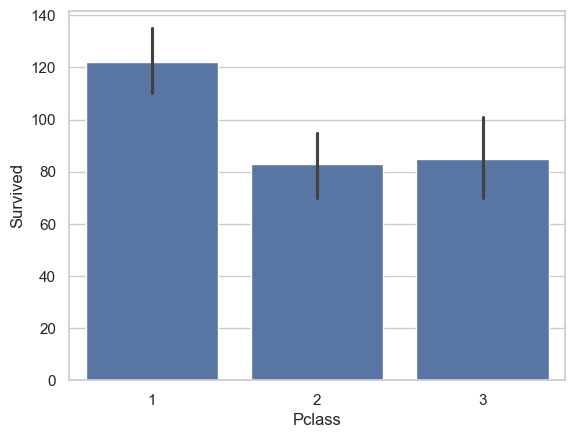

In [399]:

sns.barplot(
    df, 
    x='Pclass', 
    y='Survived', 
    estimator='sum', 

)

**Plot B** — Age distribution of survivors vs. non-survivors (histogram / KDE plot)

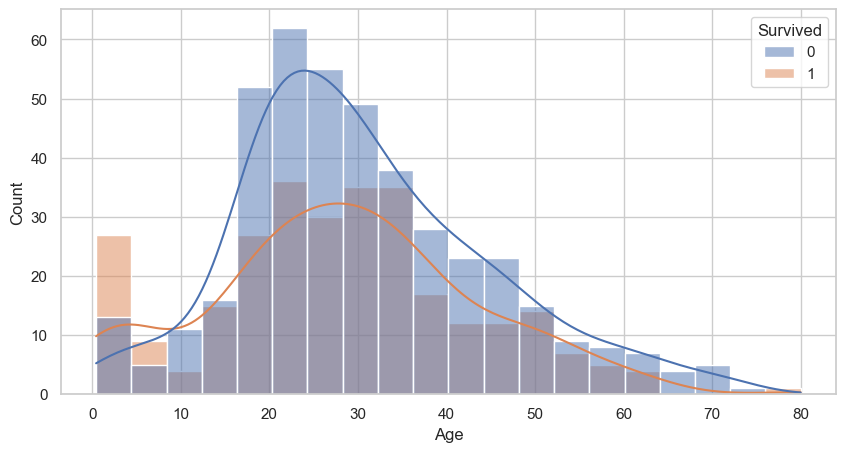

In [375]:


plt.figure(figsize=(10, 5))
sns.histplot(df, x="Age", hue="Survived", kde=True)


plt.show()

**Plot C** — Average fare by embarkation port (bar plot) — *Complete the missing line*

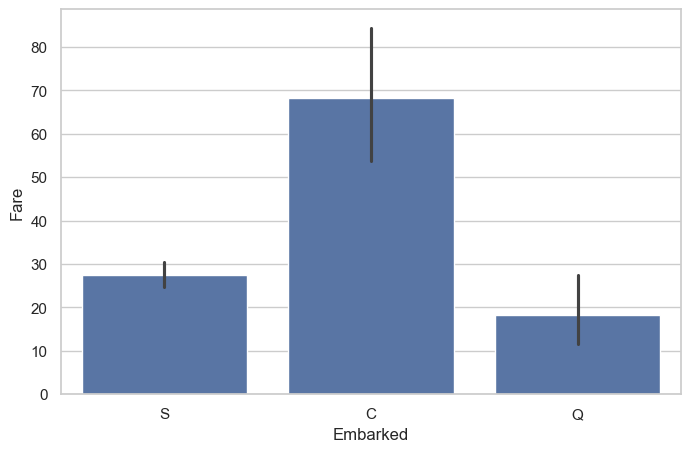

In [406]:

plt.figure(figsize=(8, 5))
sns.barplot(df, x="Embarked", y="Fare")

plt.show()

### 7. Among male passengers in 3rd class, how many survived?

In [362]:
print(df[(df.Pclass == 3) & (df.Sex == "male")]["Survived"].sum())

38


### 8. How many passengers under the age of 10 were on board, and what fraction of them survived?

*Note: Ignore passengers with missing Age values. Round the fraction to 2 decimal places.*

In [360]:
data = df.dropna(subset="Age")
survived_lt_10 = data[data.Age < 10]["Survived"].sum()
total_lt_10 = len(data[data.Age < 10])

print("number of less than 10 years old survived are: ", survived_lt_10)
print("fraction of them survived: ", np.round(survived_lt_10 / total_lt_10, 2))

number of less than 10 years old survived are:  38
fraction of them survived:  0.61


---

## Bonus Questions

### These are UNGRADED and are given as an extra challenge.

---

### Which cabin deck (first letter of the Cabin column, e.g. 'C' for 'C85') had the highest survival rate?

*Hint: Extract the first character of the `Cabin` column after dropping rows where `Cabin` is null.*

In [ ]:
df["cabin deck"] = df["Cabin"].str[0]
data = df.dropna(subset="Cabin")

data.groupby("cabin deck")["cabin deck"].value_counts()
data.groupby("cabin deck")["Survived"].sum()

deck_survival_rate = np.divide(
    data.groupby("cabin deck")["Survived"].sum(),
    data.groupby("cabin deck")["cabin deck"].value_counts(),
)

print(deck_survival_rate.sort_values(ascending=False).index[0])

D


### Extract titles from passenger names (e.g. 'Mr', 'Mrs', 'Miss') and find the most common title among survivors.

*Hint: The Name column looks like `Braund, Mr. Owen Harris` — extract the word between `, ` and `.`*

In [ ]:
# your code here
df["title"] = df["Name"].str.split(",").str[1].astype("string").str.split(".").str[0]
df.groupby("title")["Survived"].sum().sort_values(ascending=False).index[0]

' Miss'

### Plot a heatmap of the correlation matrix of all numeric columns.

*Use `seaborn.heatmap` with `annot=True`. Which two features are most positively correlated?*

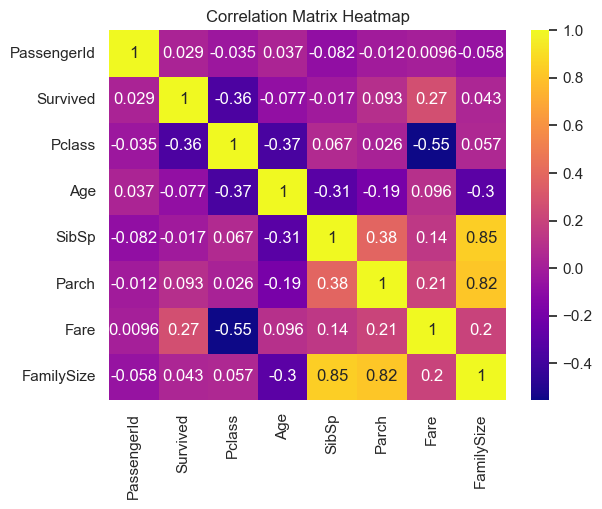

In [358]:
numeric_df = df.select_dtypes(include="number")

corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap="plasma")
plt.show()

# family size and Sibsp are mostly corelated

### Among passengers travelling alone (FamilySize == 1), what was the survival rate compared to those with family?

*You'll need to first create the `FamilySize` column (from the warm-up), then group.*

In [354]:
# your code here

family_passenger_survived = df[df["FamilySize"] == 1]["Survived"].value_counts().loc[1]
alone_passenger_survived = df[df["FamilySize"] != 1]["Survived"].value_counts().loc[1]

print(
    "survival rate of alone passengers :",
    np.round(alone_passenger_survived / len(df[df["FamilySize"] == 1]), 2),
)
print(
    "survival rate of family passengers :",
    np.round(family_passenger_survived / len(df[df["FamilySize"] != 1]), 2),
)

survival rate of alone passengers : 0.4
survival rate of family passengers : 0.42


### Which age group (bin them in 10-year intervals: 0-10, 10-20, 20-30, ...) had the lowest survival rate?

(array([38., 41., 77., 73., 34., 20.,  6.,  0.,  1.]),
 array([ 0., 10., 20., 30., 40., 50., 60., 70., 80., 90.]),
 <BarContainer object of 9 artists>)

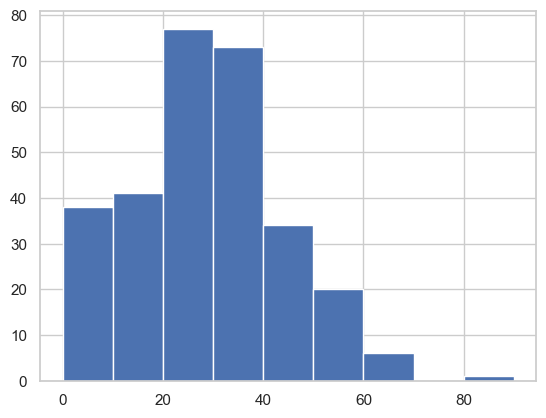

In [367]:
# your code here
plt.figure()

plt.hist(df[df['Survived']==1]['Age'], bins= [0,10,20,30,40,50,60,70,80,90,])

# 70 - 80 has lowest survival rate
